In [ ]:
import numpy as np
import pandas as pd

In [ ]:
# install transformer moels
%pip install accelerate transformers bertopic top2vec[sentence_transformers]
%pip install -i https://pypi.org/simple/ bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.6/150.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# import libraries
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import timeit
import platform
from pathlib import Path
from datetime import datetime

# Tokenization tools
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from string import punctuation
import re

# Coherence
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.utils import tokenize

# Word Clouds
from wordcloud import WordCloud

In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

In [ ]:
# class to calculate coherence score
class Metrics():

  def bert_coherence(self, sentences, topics):

    # Preprocess Documents
    documents = pd.DataFrame({
        "Document": sentences,
        "ID": range(len(sentences)),
        "Topic": topics}
    )
    documents_per_topic = documents.groupby(['Topic'], as_index=False).agg({'Document': ' '.join})
    cleaned_docs = BERTopic_model._preprocess_text(documents_per_topic.Document.values)

    # Extract vectorizer and analyzer from BERTopic
    vectorizer = BERTopic_model.vectorizer_model
    analyzer = vectorizer.build_analyzer()

    # Extract features for Topic Coherence evaluation
    words = vectorizer.get_feature_names_out()
    tokens = [analyzer(doc) for doc in cleaned_docs]
    dictionary = corpora.Dictionary(tokens)
    corpus = [dictionary.doc2bow(token) for token in tokens]
    topic_words = []
    for topic in set(topics):
        try:
            topic_data = BERTopic_model.get_topic(topic)
            if topic_data:  # Ensure the topic is valid
                topic_words.append([word for word, _ in topic_data])
        except Exception as e:
            print(f"Error processing topic {topic}: {e}")

    # Evaluate
    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokens,
        corpus=corpus,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence = coherence_model.get_coherence()
    return coherence

In [ ]:
# read the dataset
data = pd.read_csv('boomlive_data_11_2018_to_12_2024.csv', encoding='unicode_escape')
data.head()

,Category,Link,Heading,Sub_heading,Author,Date,Claim,Fact_check,Claim_summary,Claimed_by,Fact_check_summary,Links,Year,Month
0,fact check,https://www.boomlive.in/fake-news-deja-vu-vide...,fake news dÃ©jÃ vu: video of jilted man mista...,"no, this video does not show a terrorist caugh...",BOOM FACT Check Team |,2018-11-02 18:41:00,NaN,NaN,video of a terrorist nabbed in punjab disguise...,facebook user,false,['https://web.archive.org/web/20181102093455/h...,2018,11
1,fact check,https://www.boomlive.in/image-from-2014-shared...,image from 2014 shared to claim women not safe...,images of the 2014 mohanlalganj rape-murder ca...,BOOM FACT Check Team |,2018-11-06 19:05:00,NaN,NaN,image from 2014 mohanlalganj rape-murder case ...,facebook page,false,['https://www.facebook.com/YahaSabKuchmiltaha/...,2018,11
2,fact check,https://www.boomlive.in/parody-virat-kohli-twi...,parody virat kohli twitter account endorses in...,the parody account had fans believing that ind...,Nivedita Niranjankumar |,2018-11-08 14:57:00,NaN,NaN,virat kohli discontinuing endorsing foreign br...,twitter user,false,"['https://archive.is/gZ8Vy', 'https://twitter....",2018,11
3,fact check,https://www.boomlive.in/still-from-bhojpuri-mo...,still from bhojpuri movie resurfaces with fals...,once again this photo from a movie is being sh...,BOOM FACT Check Team |,2018-11-09 14:21:00,NaN,NaN,photo of mla from uttar pradesh sexually haras...,facebook user,false,['https://timesofindia.indiatimes.com/entertai...,2018,11
4,fact check,https://www.boomlive.in/video-claiming-pm-modi...,video claiming pm modi mocked demonetisation h...,parts of speech from 2016 have been edited to ...,Nivedita Niranjankumar |,2018-11-09 14:49:00,NaN,boom found that the edited portion of the vide...,video of pm narendra modi making fun of suffer...,twitter user,false,"['https://archive.is/BvC7F', 'https://twitter....",2018,11


In [ ]:
data.shape

(3607, 14)

In [ ]:
# convert date to datetime
data['Date'] = pd.to_datetime(data['Date'])

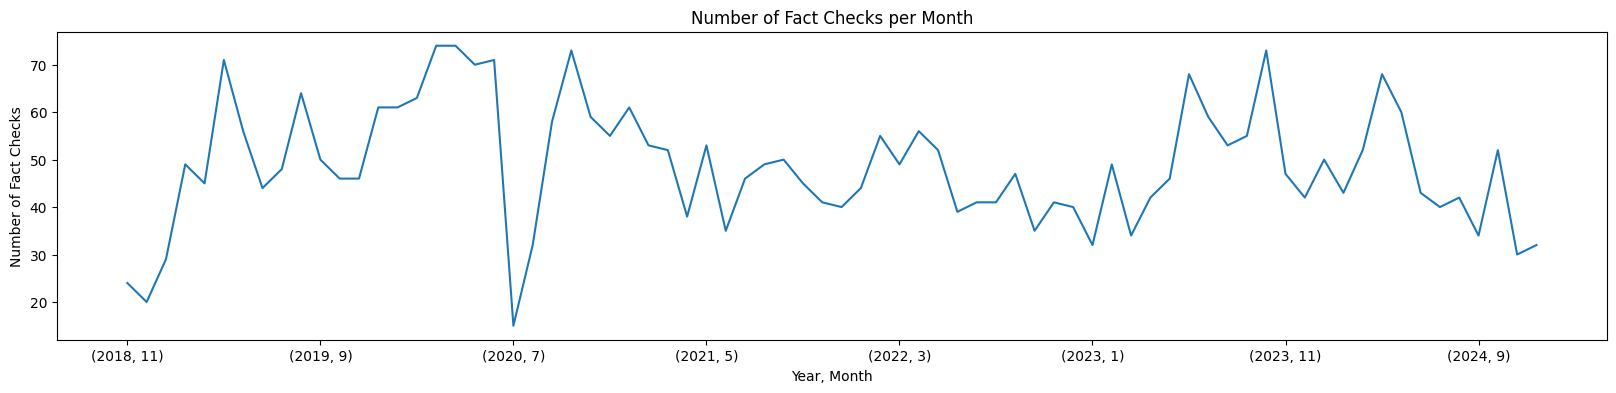

In [ ]:
# plot the number of fact checks per month
plt.figure(figsize=(20, 4))
data.groupby(['Year', 'Month']).size().plot()
plt.title('Number of Fact Checks per Month')
plt.xlabel('Year, Month')
plt.ylabel('Number of Fact Checks')
plt.show()

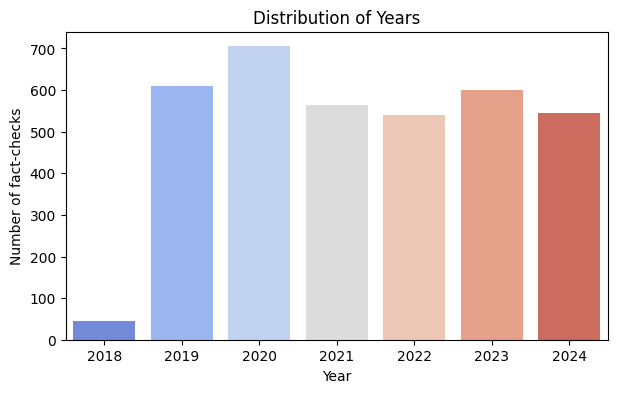

In [ ]:
# histogram of the Year column using seaborn
plt.figure(figsize=(7, 4))
sns.countplot(x='Year', data=data, palette='coolwarm')
plt.title('Distribution of Years')
plt.xlabel('Year')
plt.ylabel('Number of fact-checks')
plt.show()

In [ ]:
# convert factcheck summary to lower case
data['Fact_check_summary'] = data['Fact_check_summary'].str.lower()

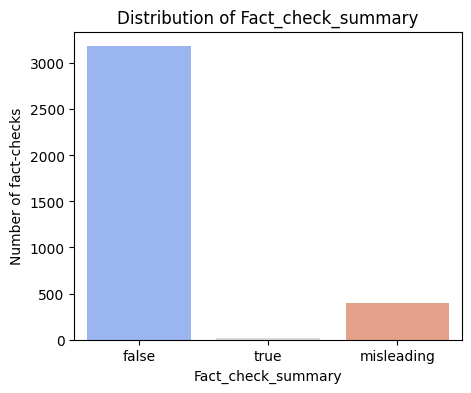

In [ ]:
# histogram of the Fact_check_summary column using seaborn
plt.figure(figsize=(5, 4))
sns.countplot(x='Fact_check_summary', data=data, palette='coolwarm')
plt.title('Distribution of Fact_check_summary')
plt.xlabel('Fact_check_summary')
plt.ylabel('Number of fact-checks')
plt.show()

In [ ]:
# for missing claims if claim summary is available replace the null with the claim summary
data['Claim'] = data['Claim'].fillna(data['Claim_summary'])

In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# preprocess the text data
# remove stopwords
stop_words = set(stopwords.words('english'))

# extract the claims
claims = data['Claim']

# drop NaN values
claims = claims.dropna()


# Custom stopwords specific to misinformation data
custom_stopwords = {'claim', 'false', 'video', 'social', 'image', 'media', 'online', 'showing', 'shows', 'show', 'viral',
                    'share', 'shared'}
all_stopwords = stop_words.union(custom_stopwords)

# Sample data
claims = claims.apply(lambda x: " ".join([word for word in x.lower().split() if word not in all_stopwords]))

In [ ]:
## lemmitization and stemming
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

# Lemmatization
lemmatizer = WordNetLemmatizer()
claims = claims.apply(lambda x: " ".join([lemmatizer.lemmatize(word) for word in x.split()]))
print(claims.head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


0    terrorist nabbed punjab disguised clothes sale...
1    2014 mohanlalganj rape-murder case woman safe ...
2    virat kohli discontinuing endorsing foreign br...
3    photo mla uttar pradesh sexually harassing poo...
4    pm narendra modi making fun suffering caused d...
Name: Claim, dtype: object


In [ ]:
# create a list of strings of claims
claims = claims.tolist()

In [ ]:
# import the embedding_model
embeddings = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# train the BERTopic model

BERTopic_model = BERTopic(
    embedding_model=embeddings,
    min_topic_size=30,
    top_n_words=100,
    verbose=True
)
topics, probs = BERTopic_model.fit_transform(claims)

2025-04-01 22:00:42,326 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/113 [00:00<?, ?it/s]

2025-04-01 22:03:31,918 - BERTopic - Embedding - Completed ✓
2025-04-01 22:03:31,921 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-04-01 22:03:53,968 - BERTopic - Dimensionality - Completed ✓
2025-04-01 22:03:53,971 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-04-01 22:03:54,300 - BERTopic - Cluster - Completed ✓
2025-04-01 22:03:54,310 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-04-01 22:03:54,599 - BERTopic - Representation - Completed ✓


In [ ]:
BERTopic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1459,-1_minister_old_photo_claim,"[minister, old, photo, claim, claiming, party,...",[2019 photo former punjab chief minister amari...
1,0,634,0_woman_man_muslim_police,"[woman, man, muslim, police, hindu, communal, ...",[disturbing karnataka man attacking woman mach...
2,1,168,1_covid_19_coronavirus_message,"[covid, 19, coronavirus, message, whatsapp, va...",[whatsapp forward describing three stage covid...
3,2,127,2_cyclone_earthquake_flood_visuals,"[cyclone, earthquake, flood, visuals, tunnel, ...","[several old video gujarat, rajasthan, massach..."
4,3,125,3_election_party_poll_bjp,"[election, party, poll, bjp, assembly, vote, s...",[two graphic claiming opinion poll predicting ...
5,4,124,4_song_dancing_singing_islamic,"[song, dancing, singing, islamic, prayer, hind...",[indian classical dance performance resurfaced...
6,5,111,5_photo_minister_modi_prime,"[photo, minister, modi, prime, narendra, gandh...",[photograph purporting prime minister narendra...
7,6,104,6_minister_modi_prime_narendra,"[minister, modi, prime, narendra, congress, le...",[post x facebook falsely claimed former presid...
8,7,100,7_air_fighter_plane_aircraft,"[air, fighter, plane, aircraft, game, helicopt...",[several photo indian female fighter pilot mis...
9,8,82,8_twitter_tweet_account_fake,"[twitter, tweet, account, fake, impersonating,...",[screenshot tweet verified twitter account cha...


In [ ]:
metrics = Metrics()
bert_coherence = metrics.bert_coherence(claims, topics)

print("BERTopic Model Metrics (Coherence): ", round(bert_coherence, 5))


BERTopic Model Metrics (Coherence):  0.5479


In [ ]:
a = BERTopic_model.get_topic_info()

In [ ]:
#save a
a.to_csv('topic_info_18_24.csv')

In [ ]:
BERTopic_model.visualize_barchart(n_words=10)

In [ ]:
a['Representation'][0][:10]

['minister',
 'old',
 'photo',
 'claim',
 'claiming',
 'party',
 'india',
 'modi',
 'indian',
 'recent']

In [ ]:
for i in range(21):
    print(f"Topic {i-1}:")
    print(a['Representation'][i][:10])
    print("\n")

Topic -1:
['minister', 'old', 'photo', 'claim', 'claiming', 'party', 'india', 'modi', 'indian', 'recent']


Topic 0:
['woman', 'man', 'muslim', 'police', 'hindu', 'communal', 'incident', 'disturbing', 'old', 'girl']


Topic 1:
['covid', '19', 'coronavirus', 'message', 'whatsapp', 'vaccine', 'claiming', 'hospital', 'outbreak', 'patient']


Topic 2:
['cyclone', 'earthquake', 'flood', 'visuals', 'tunnel', 'recent', 'heavy', 'old', 'road', 'car']


Topic 3:
['election', 'party', 'poll', 'bjp', 'assembly', 'vote', 'sabha', 'lok', 'janata', 'elections']


Topic 4:
['song', 'dancing', 'singing', 'islamic', 'prayer', 'hindu', 'muslim', 'dance', 'india', 'minister']


Topic 5:
['photo', 'minister', 'modi', 'prime', 'narendra', 'gandhi', 'leader', 'photograph', 'morphed', 'posing']


Topic 6:
['minister', 'modi', 'prime', 'narendra', 'congress', 'leader', 'gandhi', 'party', 'cropped', 'former']


Topic 7:
['air', 'fighter', 'plane', 'aircraft', 'game', 'helicopter', 'jet', 'crash', 'flight', 'mi

In [ ]:
top_docs_per_topic = BERTopic_model.get_representative_docs()
for topic_id, docs in top_docs_per_topic.items():
    print(f"Topic {topic_id}:")
    #print(f"Coherence: {coherence_scores[topic_id]}")
    print("Representative claims:")
    for doc in docs[:5]:
        print(f"- {doc}")
    print("\n")

Topic -1:
Representative claims:
- 2019 photo former punjab chief minister amarinder singh meeting home minister amit shah recent meeting singh resigned post.in photo singh shah seen shaking hands. singh resigned chief minister september 18, 2021, amid bitter infighting within congress's punjab unit public sparing congress punjab president navjot singh sidhu. dalit sikh leader charanjit singh channi took oath new chief minister state september 20, 2021.
- set two old image people carrying placard comparing prime minister narendra modi adolf hitler caption claiming picture protest held modi's recent u visit.
- old photo former prime minister manmohan singh former congress president sonia gandhi meeting bangladesh prime minister sheikh hasina sonia gandhi heading meeting despite manmohan singh prime minister india.


Topic 0:
Representative claims:
- disturbing karnataka man attacking woman machete communal spin hindu girl attacked muslim boy. boom reached hubbali police, incident occure

In [ ]:
dates = data['Date']

In [ ]:
timestamps = dates.to_list()

In [ ]:
topics_over_time = BERTopic_model.topics_over_time(claims, timestamps, nr_bins=50)

50it [00:05,  8.43it/s]


In [ ]:
BERTopic_model.visualize_topics_over_time(topics_over_time, top_n_topics=25)

In [ ]:
BERTopic_model.visualize_topics_over_time(topics_over_time, topics=[0])

In [ ]:
topics_over_time5 = BERTopic_model.topics_over_time(claims, timestamps, nr_bins=38)

38it [00:02, 13.48it/s]


In [ ]:
BERTopic_model.visualize_topics_over_time(topics_over_time5, top_n_topics=25)

In [ ]:
BERTopic_model.visualize_topics_over_time(topics_over_time5, topics=[0])

In [ ]:
BERTopic_model.visualize_topics_over_time(topics_over_time5, topics=[3])

In [ ]:
BERTopic_model.visualize_topics_over_time(topics_over_time5, topics=[14])

In [ ]:
BERTopic_model.visualize_topics_over_time(topics_over_time5, topics=[1])

In [ ]:
BERTopic_model.visualize_topics_over_time(topics_over_time5, topics=[0, 4, 14, 15, 19])

In [ ]:
BERTopic_model.visualize_topics_over_time(topics_over_time5, topics=[10])

In [ ]:
BERTopic_model.visualize_topics_over_time(topics_over_time5, topics=[3, 5, 6, 8, 9, 18])

In [ ]:
BERTopic_model.get_document_info(claims)

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,terrorist nabbed punjab disguised clothes sale...,-1,-1_minister_old_photo_claim,"[minister, old, photo, claim, claiming, party,...",[2019 photo former punjab chief minister amari...,minister - old - photo - claim - claiming - pa...,0.000000,False
1,2014 mohanlalganj rape-murder case woman safe ...,0,0_woman_man_muslim_police,"[woman, man, muslim, police, hindu, communal, ...",[disturbing karnataka man attacking woman mach...,woman - man - muslim - police - hindu - commun...,1.000000,False
2,virat kohli discontinuing endorsing foreign br...,17,17_food_beef_meat_meal,"[food, beef, meat, meal, serving, mcdonald, do...","[message claim court hearing tamil nadu, musli...",food - beef - meat - meal - serving - mcdonald...,1.000000,False
3,photo mla uttar pradesh sexually harassing poo...,0,0_woman_man_muslim_police,"[woman, man, muslim, police, hindu, communal, ...",[disturbing karnataka man attacking woman mach...,woman - man - muslim - police - hindu - commun...,1.000000,False
4,pm narendra modi making fun suffering caused d...,6,6_minister_modi_prime_narendra,"[minister, modi, prime, narendra, congress, le...",[post x facebook falsely claimed former presid...,minister - modi - prime - narendra - congress ...,0.902763,False
...,...,...,...,...,...,...,...,...
3602,bjp delhi claiming depict pothole-filled road ...,2,2_cyclone_earthquake_flood_visuals,"[cyclone, earthquake, flood, visuals, tunnel, ...","[several old video gujarat, rajasthan, massach...",cyclone - earthquake - flood - visuals - tunne...,1.000000,False
3603,hindu woman raped tortured araihazar village n...,0,0_woman_man_muslim_police,"[woman, man, muslim, police, hindu, communal, ...",[disturbing karnataka man attacking woman mach...,woman - man - muslim - police - hindu - commun...,1.000000,False
3604,former indian prime minister manmohan singh to...,-1,-1_minister_old_photo_claim,"[minister, old, photo, claim, claiming, party,...",[2019 photo former punjab chief minister amari...,minister - old - photo - claim - claiming - pa...,0.000000,False
3605,couple publicly flogged bangladesh,0,0_woman_man_muslim_police,"[woman, man, muslim, police, hindu, communal, ...",[disturbing karnataka man attacking woman mach...,woman - man - muslim - police - hindu - commun...,1.000000,False


In [ ]:
# save the adatframe
BERTopic_model.get_document_info(claims).to_csv('document_info_18_24.csv')

In [ ]:
BERTopic_model.visualize_topics_over_time(topics_over_time5, topics=[3, 5, 6, 8, 9, 18])

In [ ]:
# read document info
document_info = pd.read_csv('document_info_18_24.csv')

In [ ]:
# add topic column from document info to the data
data['Topic'] = document_info['Topic']

In [ ]:
data.head()

,Category,Link,Heading,Sub_heading,Author,Date,Claim,Fact_check,Claim_summary,Claimed_by,Fact_check_summary,Links,Year,Month,Topic
0,fact check,https://www.boomlive.in/fake-news-deja-vu-vide...,fake news dÃ©jÃ vu: video of jilted man mista...,"no, this video does not show a terrorist caugh...",BOOM FACT Check Team |,2018-11-02 18:41:00,video of a terrorist nabbed in punjab disguise...,NaN,video of a terrorist nabbed in punjab disguise...,facebook user,false,['https://web.archive.org/web/20181102093455/h...,2018,11,-1
1,fact check,https://www.boomlive.in/image-from-2014-shared...,image from 2014 shared to claim women not safe...,images of the 2014 mohanlalganj rape-murder ca...,BOOM FACT Check Team |,2018-11-06 19:05:00,image from 2014 mohanlalganj rape-murder case ...,NaN,image from 2014 mohanlalganj rape-murder case ...,facebook page,false,['https://www.facebook.com/YahaSabKuchmiltaha/...,2018,11,0
2,fact check,https://www.boomlive.in/parody-virat-kohli-twi...,parody virat kohli twitter account endorses in...,the parody account had fans believing that ind...,Nivedita Niranjankumar |,2018-11-08 14:57:00,virat kohli discontinuing endorsing foreign br...,NaN,virat kohli discontinuing endorsing foreign br...,twitter user,false,"['https://archive.is/gZ8Vy', 'https://twitter....",2018,11,17
3,fact check,https://www.boomlive.in/still-from-bhojpuri-mo...,still from bhojpuri movie resurfaces with fals...,once again this photo from a movie is being sh...,BOOM FACT Check Team |,2018-11-09 14:21:00,photo of mla from uttar pradesh sexually haras...,NaN,photo of mla from uttar pradesh sexually haras...,facebook user,false,['https://timesofindia.indiatimes.com/entertai...,2018,11,0
4,fact check,https://www.boomlive.in/video-claiming-pm-modi...,video claiming pm modi mocked demonetisation h...,parts of speech from 2016 have been edited to ...,Nivedita Niranjankumar |,2018-11-09 14:49:00,video of pm narendra modi making fun of suffer...,boom found that the edited portion of the vide...,video of pm narendra modi making fun of suffer...,twitter user,false,"['https://archive.is/BvC7F', 'https://twitter....",2018,11,6


In [ ]:
df = data.copy()

In [ ]:
df.head()

,Category,Link,Heading,Sub_heading,Author,Date,Claim,Fact_check,Claim_summary,Claimed_by,Fact_check_summary,Links,Year,Month,Topic,year_month
0,fact check,https://www.boomlive.in/fake-news-deja-vu-vide...,fake news dÃ©jÃ vu: video of jilted man mista...,"no, this video does not show a terrorist caugh...",BOOM FACT Check Team |,2018-11-02 18:41:00,video of a terrorist nabbed in punjab disguise...,NaN,video of a terrorist nabbed in punjab disguise...,facebook user,false,['https://web.archive.org/web/20181102093455/h...,2018,11,-1,2018-11-01
1,fact check,https://www.boomlive.in/image-from-2014-shared...,image from 2014 shared to claim women not safe...,images of the 2014 mohanlalganj rape-murder ca...,BOOM FACT Check Team |,2018-11-06 19:05:00,image from 2014 mohanlalganj rape-murder case ...,NaN,image from 2014 mohanlalganj rape-murder case ...,facebook page,false,['https://www.facebook.com/YahaSabKuchmiltaha/...,2018,11,0,2018-11-01
2,fact check,https://www.boomlive.in/parody-virat-kohli-twi...,parody virat kohli twitter account endorses in...,the parody account had fans believing that ind...,Nivedita Niranjankumar |,2018-11-08 14:57:00,virat kohli discontinuing endorsing foreign br...,NaN,virat kohli discontinuing endorsing foreign br...,twitter user,false,"['https://archive.is/gZ8Vy', 'https://twitter....",2018,11,17,2018-11-01
3,fact check,https://www.boomlive.in/still-from-bhojpuri-mo...,still from bhojpuri movie resurfaces with fals...,once again this photo from a movie is being sh...,BOOM FACT Check Team |,2018-11-09 14:21:00,photo of mla from uttar pradesh sexually haras...,NaN,photo of mla from uttar pradesh sexually haras...,facebook user,false,['https://timesofindia.indiatimes.com/entertai...,2018,11,0,2018-11-01
4,fact check,https://www.boomlive.in/video-claiming-pm-modi...,video claiming pm modi mocked demonetisation h...,parts of speech from 2016 have been edited to ...,Nivedita Niranjankumar |,2018-11-09 14:49:00,video of pm narendra modi making fun of suffer...,boom found that the edited portion of the vide...,video of pm narendra modi making fun of suffer...,twitter user,false,"['https://archive.is/BvC7F', 'https://twitter....",2018,11,6,2018-11-01


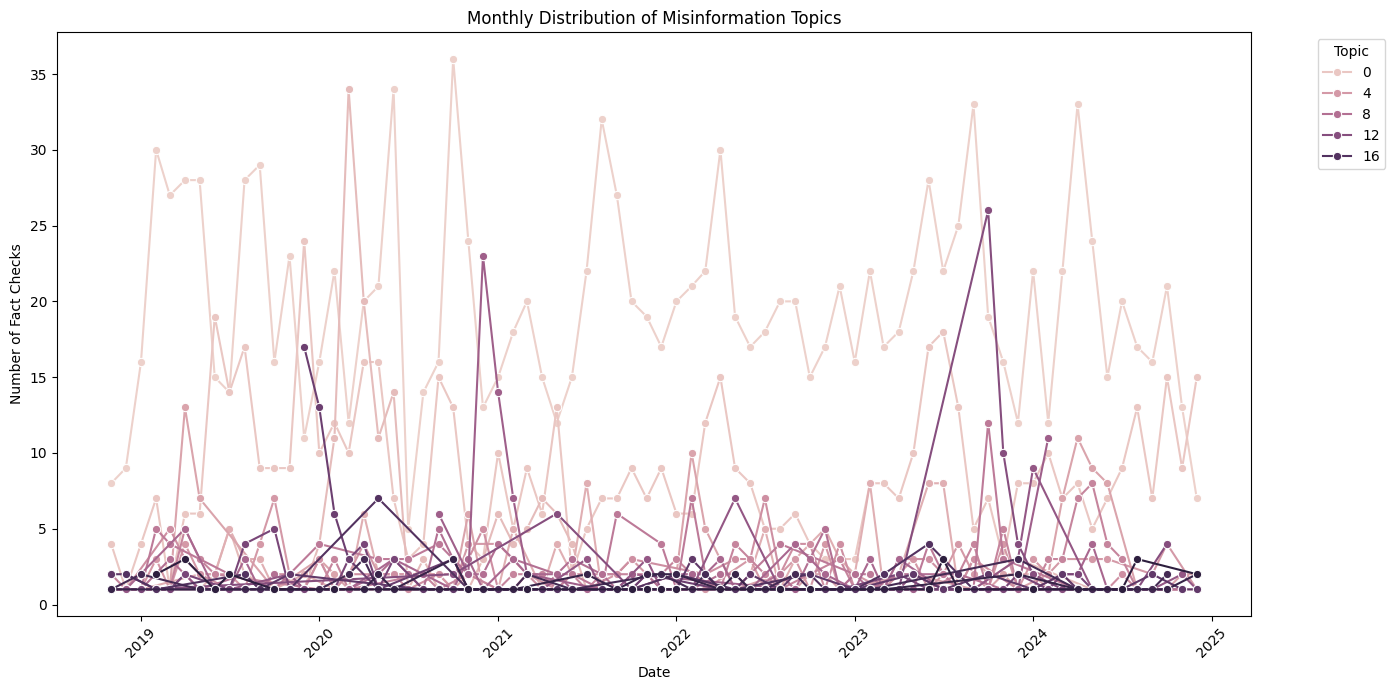

In [ ]:
df['year_month'] = pd.to_datetime(df[['Year', 'Month']].assign(day=1))

# Group by year_month and topic
topic_counts = df.groupby(['year_month', 'Topic']).size().reset_index(name='count')

# Plotting
plt.figure(figsize=(14, 7))
sns.lineplot(data=topic_counts, x='year_month', y='count', hue='Topic', marker='o')

plt.title('Monthly Distribution of Misinformation Topics')
plt.xlabel('Date')
plt.ylabel('Number of Fact Checks')
plt.xticks(rotation=45)
plt.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
topic_counts

,year_month,Topic,count
0,2018-11-01,-1,8
1,2018-11-01,0,4
2,2018-11-01,1,1
3,2018-11-01,2,1
4,2018-11-01,5,1
...,...,...,...
815,2024-12-01,4,1
816,2024-12-01,11,1
817,2024-12-01,15,1
818,2024-12-01,18,2


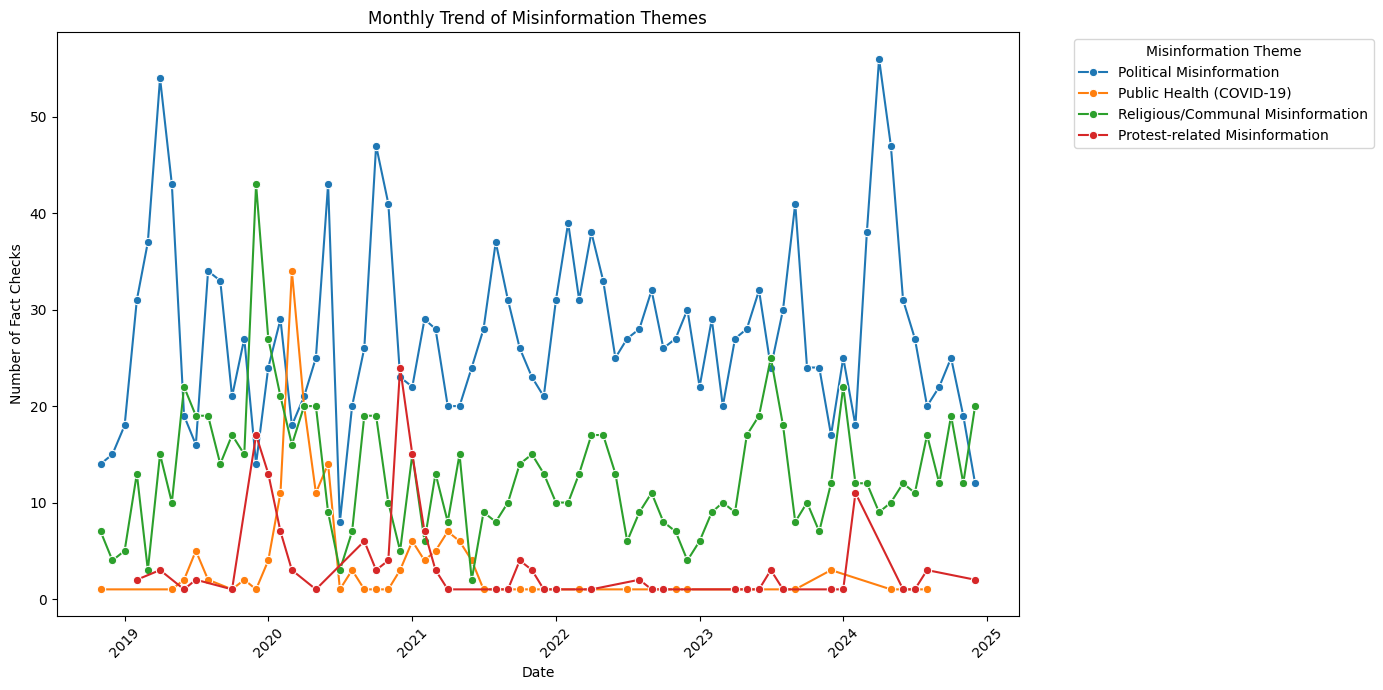

In [ ]:
# 1. Define topic groups by high-level theme
theme_groups = {
    "Political Misinformation": [-1, 3, 5, 6, 8, 9, 15, 18],
    "Religious/Communal Misinformation": [0, 4, 11, 14, 15, 19],
    "Public Health (COVID-19)": [1],
    "Protest-related Misinformation": [10, 14, 19]
}

# 2. Reverse mapping: topic number -> theme
topic_to_theme = {}
for theme, topics in theme_groups.items():
    for topic in topics:
        topic_to_theme.setdefault(topic, []).append(theme)  # supports overlap

# 3. Convert topic column to themes (explodes if a topic belongs to multiple themes)
df['year_month'] = pd.to_datetime(df[['Year', 'Month']].assign(day=1))
df['theme'] = df['Topic'].map(topic_to_theme)

# 4. Explode in case of overlap (e.g., topic 14 belongs to two themes)
df_exploded = df.explode('theme').dropna(subset=['theme'])

# 5. Group by year_month and theme, count occurrences
grouped = df_exploded.groupby(['year_month', 'theme']).size().reset_index(name='count')

# 6. Plotting
plt.figure(figsize=(14, 7))
sns.lineplot(data=grouped, x='year_month', y='count', hue='theme', marker='o')

plt.title('Monthly Trend of Misinformation Themes')
plt.xlabel('Date')
plt.ylabel('Number of Fact Checks')
plt.xticks(rotation=45)
plt.legend(title='Misinformation Theme', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

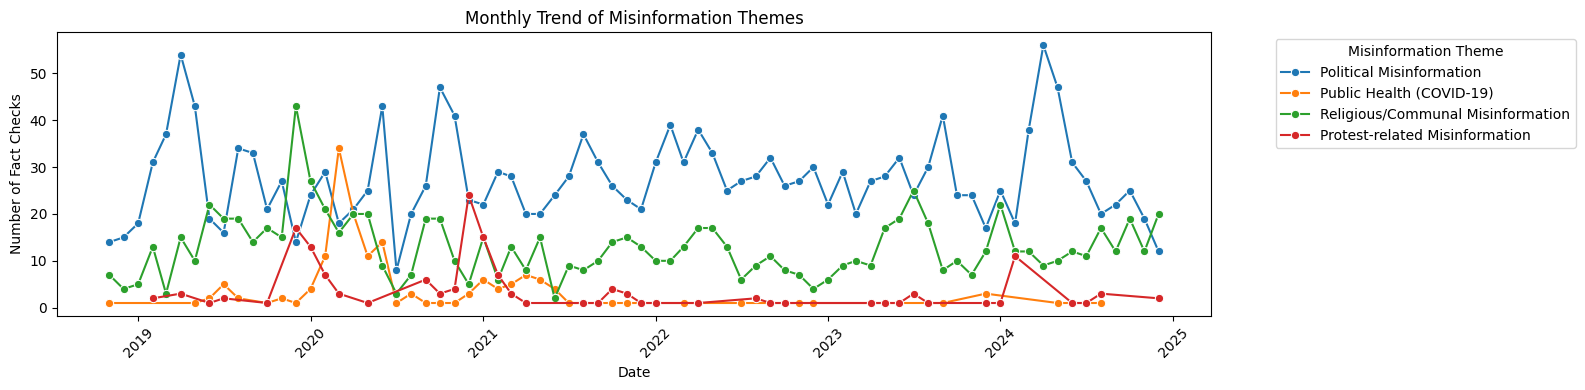

In [ ]:
plt.figure(figsize=(16, 4))
sns.lineplot(data=grouped, x='year_month', y='count', hue='theme', marker='o')

plt.title('Monthly Trend of Misinformation Themes')
plt.xlabel('Date')
plt.ylabel('Number of Fact Checks')
plt.xticks(rotation=45)
plt.legend(title='Misinformation Theme', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

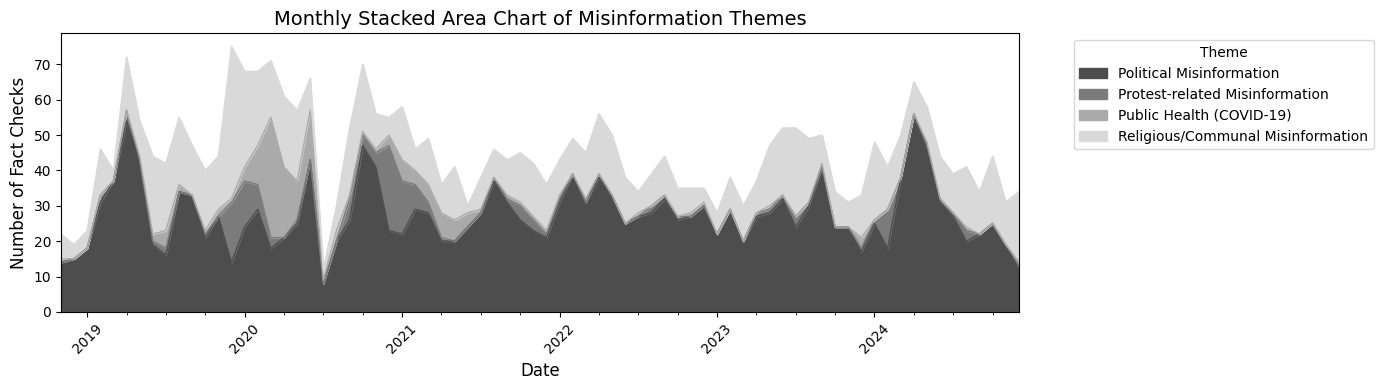

In [ ]:
num_themes = len(pivot_df.columns)
grey_colors = [str(g) for g in np.linspace(0.3, 0.85, num_themes)]
pivot_df.plot.area(
    figsize=(14, 4),
    color=grey_colors,  # Try 'Pastel1', 'Pastel2', or 'Set3' for light colors
    linewidth=1
)

plt.title('Monthly Stacked Area Chart of Misinformation Themes', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Fact Checks', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Theme', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()